In [ ]:
install.packages("sqldf")

library(sqldf)

deliveries <- read.csv("deliveries.csv")

sqldf("
SELECT delivery_status, COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY delivery_status;
")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



delivery_status,total_deliveries
<chr>,<int>
Delayed,202
Failed,132
OnTime,616


In [ ]:
vehicles <- read.csv("vehicles.csv")

sqldf("
SELECT assigned_zone, COUNT(*) AS total_vehicles
FROM vehicles
GROUP BY assigned_zone;
")

assigned_zone,total_vehicles
<chr>,<int>
AIRPORT,13
Airport,1
CENTRAL,10
Central,6
Ctr,6
EAST,8
East,12
NORTH,7
North,9


In [ ]:
incidents <- read.csv("incidents.csv")

sqldf("
SELECT incident_type, COUNT(*) AS total_incidents
FROM incidents
GROUP BY incident_type;
")

incident_type,total_incidents
<chr>,<int>
AppSyncError,31
BatteryAlert,36
CustomerNoShow,44
ProofMissing,46
RouteDeviation,43
SafetyNearMiss,14
TemperatureIssue,29
VehicleFault,37


In [ ]:
complaints <- read.csv("complaints.csv")

sqldf("
SELECT severity, COUNT(*) AS total_complaints
FROM complaints
GROUP BY severity;
")

severity,total_complaints
<chr>,<int>
High,77
Low,71
Medium,172


In [ ]:
sqldf("
EXPLAIN QUERY PLAN
SELECT delivery_status, COUNT(*)
FROM deliveries
GROUP BY delivery_status;
")

id,parent,notused,detail
<int>,<int>,<int>,<chr>
6,0,216,SCAN deliveries
8,0,0,USE TEMP B-TREE FOR GROUP BY


In [ ]:
install.packages("sqldf")
library(sqldf)
vehicles <- read.csv("vehicles.csv")
sqldf("
SELECT assigned_zone, COUNT(*) AS total_vehicles
FROM vehicles
GROUP BY assigned_zone
ORDER BY total_vehicles DESC
")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite



assigned_zone,total_vehicles
<chr>,<int>
AIRPORT,13
East,12
Riverside,10
CENTRAL,10
North,9
WEST,8
South,8
EAST,8
NORTH,7


In [ ]:
deliveries <- read.csv("deliveries.csv")

sqldf("
SELECT delivery_status, COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY delivery_status
")

delivery_status,total_deliveries
<chr>,<int>
Delayed,202
Failed,132
OnTime,616


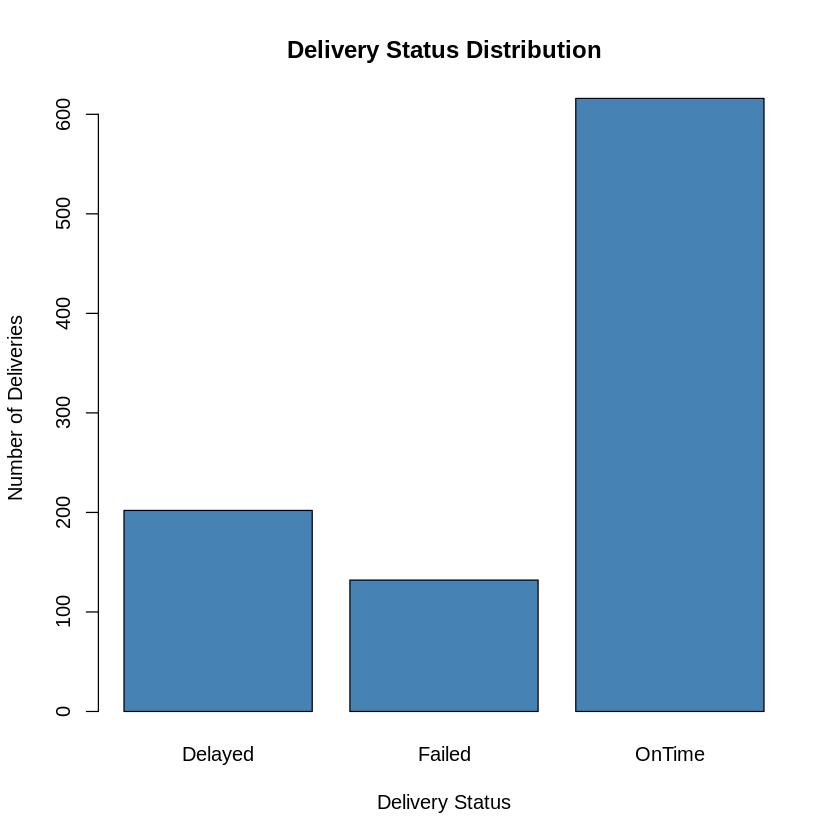

In [ ]:
delivery_counts <- sqldf("
SELECT delivery_status, COUNT(*) AS total
FROM deliveries
GROUP BY delivery_status
")

barplot(
  delivery_counts$total,
  names.arg = delivery_counts$delivery_status,
  col = "steelblue",
  main = "Delivery Status Distribution",
  xlab = "Delivery Status",
  ylab = "Number of Deliveries"
)

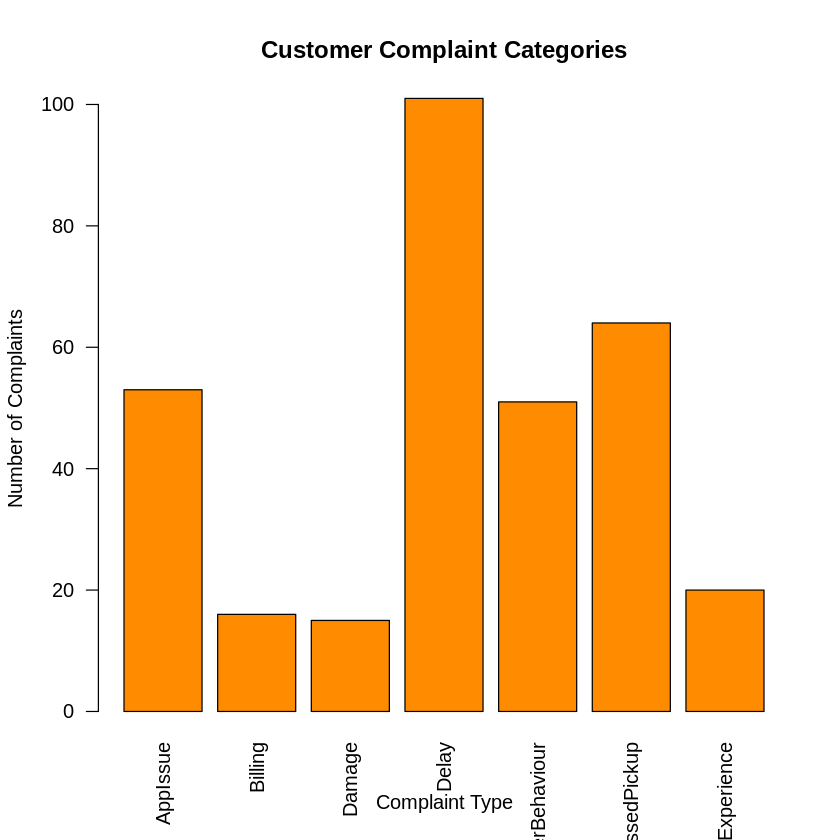

In [ ]:
complaints <- read.csv("complaints.csv")

complaint_counts <- sqldf("
SELECT complaint_type, COUNT(*) AS total
FROM complaints
GROUP BY complaint_type
")

barplot(
  complaint_counts$total,
  names.arg = complaint_counts$complaint_type,
  col = "darkorange",
  main = "Customer Complaint Categories",
  xlab = "Complaint Type",
  ylab = "Number of Complaints",
  las = 2
)

In [ ]:
drivers <- read.csv("drivers.csv")
deliveries <- read.csv("deliveries.csv")

sqldf("
SELECT drivers.driver_id,
       deliveries.delivery_status
FROM drivers
JOIN deliveries
ON drivers.driver_id = deliveries.driver_id
LIMIT 10;
")

driver_id,delivery_status
<chr>,<chr>
D001,Delayed
D001,Failed
D001,OnTime
D001,OnTime
D001,OnTime
D001,OnTime
D002,Delayed
D002,Delayed
D002,Failed
